In [1]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from astropy.cosmology import FlatLambdaCDM

# To be able to see the plots in the browser
%matplotlib inline

In [2]:
# sql qury to cosmohub
# SELECT lmhalo 
# FROM micecatv2_0_view 
# where z_cgal between 0.90 and 1.10 and flag_central = 0 and dec_gal > 70.

In [3]:
halo_cat = pd.read_csv('/Users/fjc/6936.csv.bz2', sep=",", comment='#', na_values=r'\N')

In [4]:
halo_cat.columns

Index(['lmhalo'], dtype='object')

In [5]:
halo_cat.shape

(3280928, 1)

In [6]:
lm_min = np.amin(halo_cat['lmhalo'])
lm_max = np.amax(halo_cat['lmhalo'])
print ('lm_min=',lm_min,' lmmax=',lm_max)

lm_min= 11.0101  lmmax= 14.5902


In [7]:
lm_bins = np.linspace(lm_min,lm_max,101)
#bins
print (lm_bins.shape)

(101,)


In [8]:
lm_hist, lm_edges = np.histogram(halo_cat['lmhalo'], bins=lm_bins)

In [9]:
print (lm_hist.shape)
print (lm_edges.shape)

(100,)
(101,)


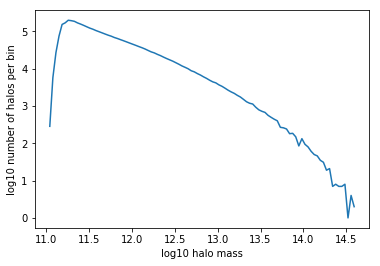

In [10]:
plt.plot(lm_edges[1:],np.log10(lm_hist))
plt.xlabel('log10 halo mass')
plt.ylabel('log10 number of halos per bin')

In [11]:
lm_hist_error = np.sqrt(lm_hist)

In [12]:
# compute the volume
cosmo = FlatLambdaCDM(H0=100., Om0=0.25, Ob0=0.049, Tcmb0=2.725)

In [13]:
vol09 = cosmo.comoving_volume(0.9)  # volume inside z=0.9
vol11 = cosmo.comoving_volume(1.1)  # volume inside z=1.1

volume = vol11 - vol09
volume.value

25810418926.93183

In [14]:
area = np.pi/2*(1.-np.sin(70.*np.pi/180.))
area_deg = area * 180.*180. / np.pi/np.pi
print ('area =',area,'sr ',area_deg,'deg2')

area = 0.09473060974812211 sr  310.98224722161973 deg2


In [15]:
vol = volume.value/(4.*np.pi)*area
print ('volume =',vol)

volume = 194569840.2376309


In [16]:
delta_lm = lm_edges[1] - lm_edges[0]

In [17]:
print (vol)
print (delta_lm)

194569840.2376309
0.035800999999999306


In [18]:
lm_abun = lm_hist / vol / delta_lm

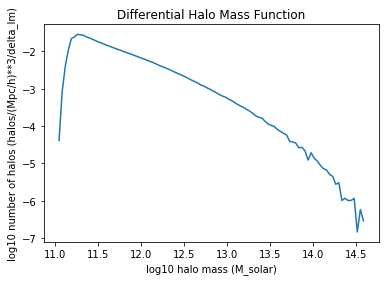

In [19]:
plt.plot(lm_edges[1:],np.log10(lm_abun))
plt.xlabel('log10 halo mass (M_solar)')
plt.ylabel('log10 number of halos (halos/(Mpc/h)**3/delta_lm)')
plt.title('Differential Halo Mass Function')

In [20]:
# cumulative

lm_hist_cum = np.flipud(np.cumsum(np.flipud(lm_hist)))

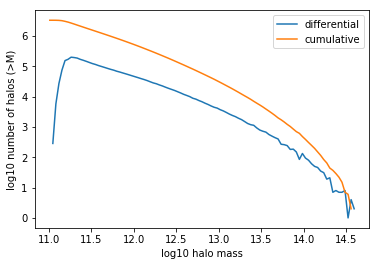

In [21]:
plt.plot(lm_edges[1:],np.log10(lm_hist),label='differential')
plt.plot(lm_edges[:-1],np.log10(lm_hist_cum),label='cumulative')
plt.xlabel('log10 halo mass')
plt.ylabel('log10 number of halos (>M)')
plt.legend()

In [22]:
lm_abun_cum = lm_hist_cum / vol 

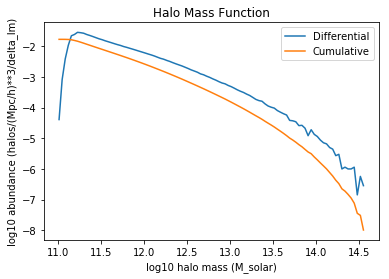

In [23]:
plt.plot(lm_edges[:-1],np.log10(lm_abun),label='Differential')
plt.plot(lm_edges[:-1],np.log10(lm_abun_cum),label='Cumulative')
plt.xlabel('log10 halo mass (M_solar)')
plt.ylabel('log10 abundance (halos/(Mpc/h)**3/delta_lm)')
plt.title('Halo Mass Function')
plt.legend()

In [24]:
# compare with theory
import hmf

In [25]:
hmf_z10_Tinker = hmf.MassFunction(cosmo_model=cosmo,n=0.95,sigma_8=0.8,z=1.0,transfer_model='EH',
                           Mmin=lm_min,Mmax=lm_max,dlog10m=0.01,delta_h=200.0,delta_wrt='mean',delta_c=1.686)

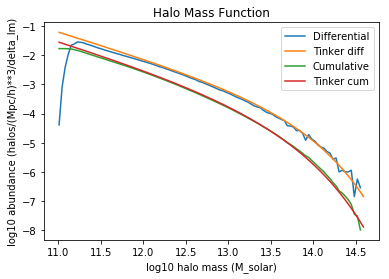

In [26]:
plt.plot(lm_edges[:-1],np.log10(lm_abun),label='Differential')
plt.plot(np.log10(hmf_z10_Tinker.m),np.log10(hmf_z10_Tinker.dndlog10m),label='Tinker diff')
plt.plot(lm_edges[:-1],np.log10(lm_abun_cum),label='Cumulative')
plt.plot(np.log10(hmf_z10_Tinker.m),np.log10(hmf_z10_Tinker.ngtm),label='Tinker cum')
plt.xlabel('log10 halo mass (M_solar)')
plt.ylabel('log10 abundance (halos/(Mpc/h)**3/delta_lm)')
plt.title('Halo Mass Function')
plt.legend()

In [27]:
#np.log10(hmf_z10_Tinker.ngtm)


In [28]:
#hmf_z10_Tinker.parameter_info()
#hmf_z10_Tinker.parameter_values